Import Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense,Dropout

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

Load Dataset

In [ ]:
df=pd.read_csv("/content/fake reviews dataset.csv")
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


Info Gathering

In [ ]:
print(df.shape)

(40432, 4)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB


In [ ]:
df.describe(include="all")

,category,rating,label,text_
count,40432,40432.000000,40432,40432
unique,10,NaN,2,40412
top,Kindle_Store_5,NaN,CG,My dog loves these and it has kept her occupie...
freq,4730,NaN,20216,2
mean,NaN,4.256579,NaN,NaN
std,NaN,1.144354,NaN,NaN
min,NaN,1.000000,NaN,NaN
25%,NaN,4.000000,NaN,NaN
50%,NaN,5.000000,NaN,NaN
75%,NaN,5.000000,NaN,NaN


In [ ]:
df.isnull().sum()

,0
category,0
rating,0
label,0
text_,0


In [ ]:
print(df.duplicated().sum())

12


Data Manipulation

In [ ]:
df=df.drop_duplicates()
df.shape

(40420, 4)

In [ ]:
df["label"].value_counts()

,count
label,
OR,20215
CG,20205


In [ ]:
df["text_"]=df["text_"].astype(str).str.lower()
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"love this! well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. i..."
2,Home_and_Kitchen_5,5.0,CG,this pillow saved my back. i love the look and...
3,Home_and_Kitchen_5,1.0,CG,"missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,very nice set. good quality. we have had the s...


In [ ]:
encoder=LabelEncoder()
df["label"]=encoder.fit_transform(df["label"])
df.head()

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,0,"love this! well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,0,"love it, a great upgrade from the original. i..."
2,Home_and_Kitchen_5,5.0,0,this pillow saved my back. i love the look and...
3,Home_and_Kitchen_5,1.0,0,"missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,0,very nice set. good quality. we have had the s...


Data Visualization

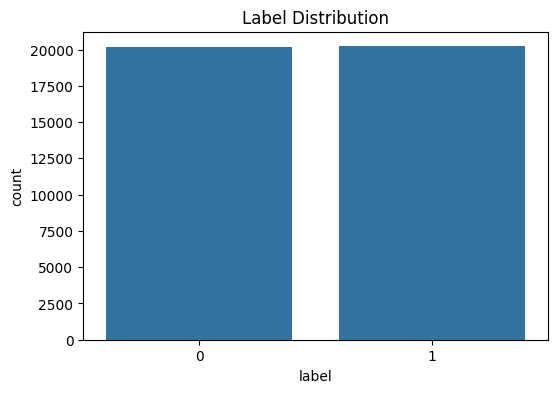

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["label"])
plt.title("Label Distribution")
plt.show()

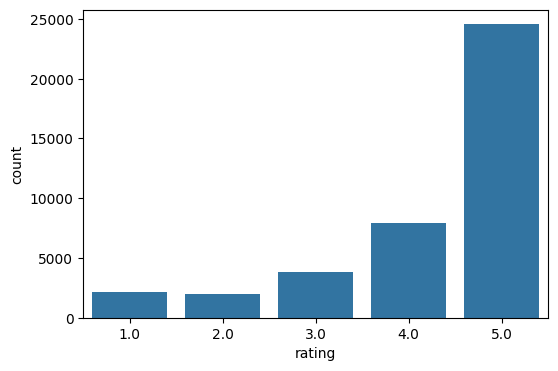

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["rating"])
plt.show()

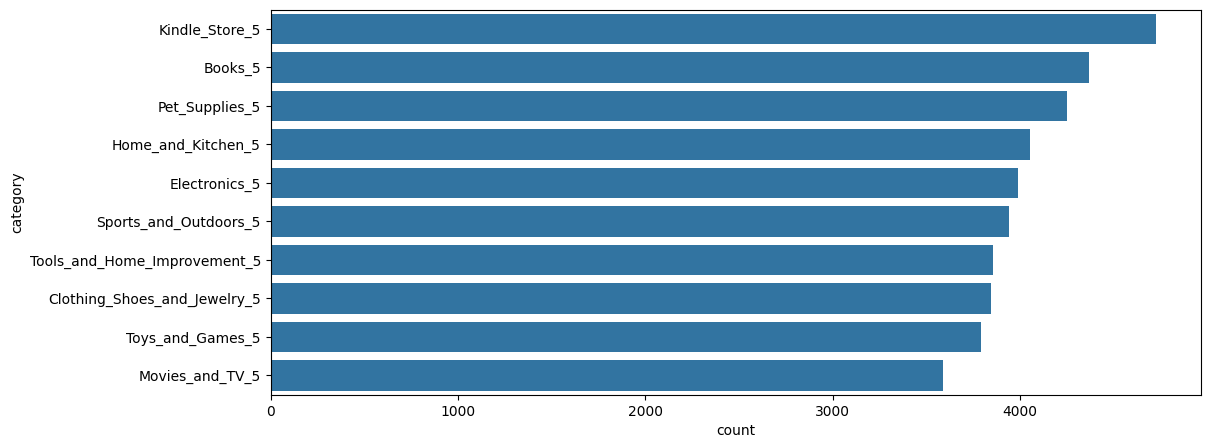

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(y=df["category"],order=df["category"].value_counts().index)
plt.show()

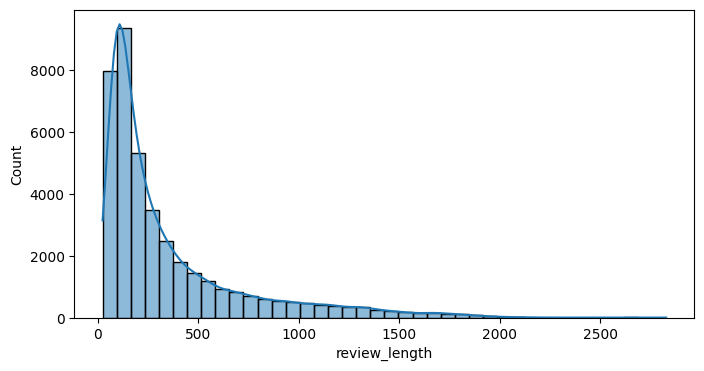

In [ ]:
df["review_length"]=df["text_"].apply(len)

plt.figure(figsize=(8,4))
sns.histplot(df["review_length"],bins=40,kde=True)
plt.show()

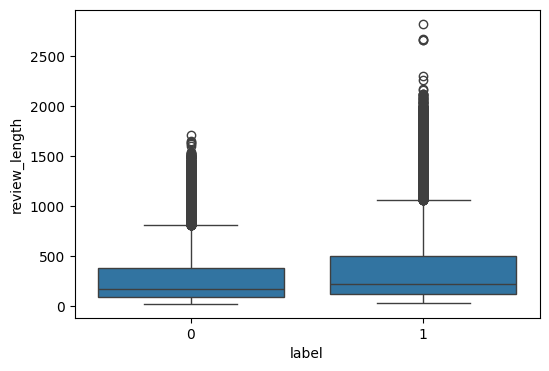

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["label"],y=df["review_length"])
plt.show()

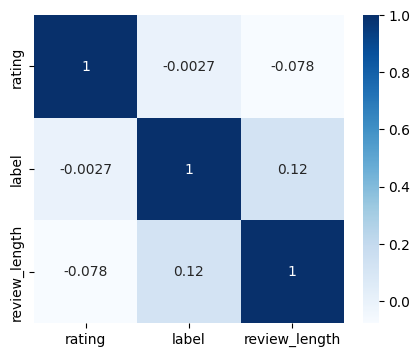

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(df[["rating","label","review_length"]].corr(),annot=True,cmap="Blues")
plt.show()

X and Y Split

In [ ]:
X=df["text_"]
y=df["label"]

In [ ]:
tokenizer=Tokenizer(num_words=10000,oov_token="<OOV>")
tokenizer.fit_on_texts(X)
sequences=tokenizer.texts_to_sequences(X)
X=pad_sequences(sequences,maxlen=150,padding="post")

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model=Sequential()

model.add(Embedding(10000,128,input_length=150))
model.add(LSTM(64))
model.add(Dropout(0.5))
model.add(Dense(32,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Data Tranning

In [ ]:
history=model.fit(X_train,y_train,epochs=10,batch_size=32,validation_split=0.2)

Epoch 1/10
809/809 ━━━━━━━━━━━━━━━━━━━━ 97s 115ms/step - accuracy: 0.5500 - loss: 0.6554 - val_accuracy: 0.5866 - val_loss: 0.6164
Epoch 2/10
809/809 ━━━━━━━━━━━━━━━━━━━━ 141s 115ms/step - accuracy: 0.8585 - loss: 0.3155 - val_accuracy: 0.9148 - val_loss: 0.2275
Epoch 3/10
809/809 ━━━━━━━━━━━━━━━━━━━━ 142s 115ms/step - accuracy: 0.9461 - loss: 0.1460 - val_accuracy: 0.9382 - val_loss: 0.1600
Epoch 4/10
809/809 ━━━━━━━━━━━━━━━━━━━━ 93s 115ms/step - accuracy: 0.9661 - loss: 0.0940 - val_accuracy: 0.9300 - val_loss: 0.2240
Epoch 5/10
809/809 ━━━━━━━━━━━━━━━━━━━━ 93s 115ms/step - accuracy: 0.9773 - loss: 0.0636 - val_accuracy: 0.9275 - val_loss: 0.1913
Epoch 6/10
809/809 ━━━━━━━━━━━━━━━━━━━━ 93s 115ms/step - accuracy: 0.9849 - loss: 0.0411 - val_accuracy: 0.9351 - val_loss: 0.2479
Epoch 7/10
809/809 ━━━━━━━━━━━━━━━━━━━━ 93s 115ms/step - accuracy: 0.9881 - loss: 0.0365 - val_accuracy: 0.9341 - val_loss: 0.2856
Epoch 8/10
809/809 ━━━━━━━━━━━━━━━━━━━━ 142s 115ms/step - accuracy: 0.9901 - loss

In [ ]:
loss,accuracy=model.evaluate(X_test,y_test)
print("Test Loss:",loss)
print("Test Accuracy:",accuracy)

253/253 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.9356 - loss: 0.3244
Test Loss: 0.324425607919693
Test Accuracy: 0.9355517029762268


In [ ]:
prediction=model.predict(X_test)
prediction=(prediction>0.5).astype(int)

253/253 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step


In [ ]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

           0       0.94      0.93      0.94      4055
           1       0.93      0.94      0.94      4029

    accuracy                           0.94      8084
   macro avg       0.94      0.94      0.94      8084
weighted avg       0.94      0.94      0.94      8084



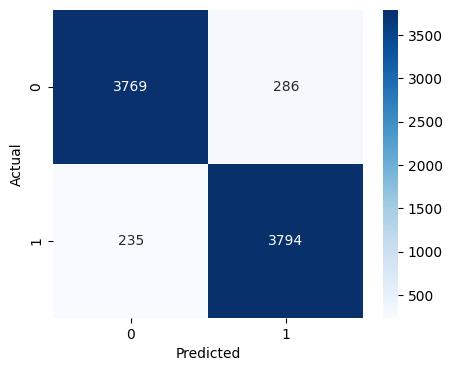

In [ ]:
cm=confusion_matrix(y_test,prediction)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

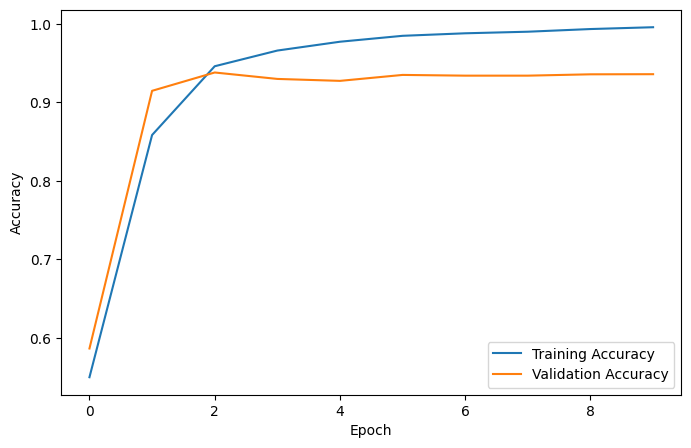

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

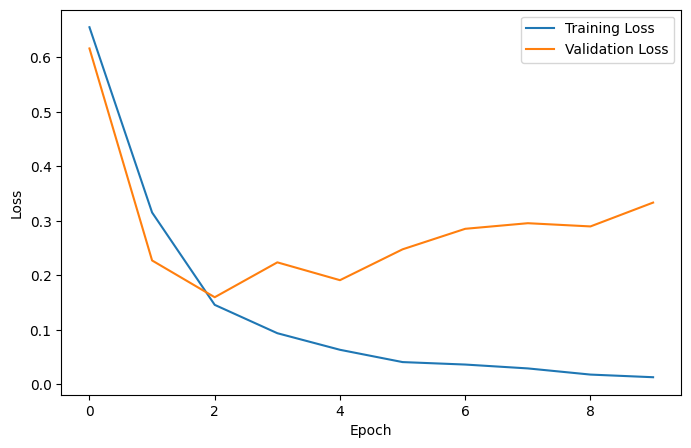

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
review=["This product is amazing and worth buying"]

seq=tokenizer.texts_to_sequences(review)
pad=pad_sequences(seq,maxlen=150,padding="post")

pred=model.predict(pad)

if pred[0][0]>0.5:
    print("Prediction : Genuine Review")
else:
    print("Prediction : Fake Review")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Prediction : Genuine Review
